In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import trimesh
from io import StringIO
import requests

Load refractive indices from Mastrapa et al. 2008, 2009

In [2]:
url = "https://content.cld.iop.org/journals/0004-637X/701/2/1347/revision1/apj315328t8_mrt.txt"
response = requests.get(url)
table_ascii = None
if response.status_code == 200:
    table_ascii = response.text

    df = pd.read_fwf(
        StringIO(table_ascii),
        colspecs=[(0, 11), (12, 15), (16, 26), (27, 37), (38, 51)],
        names=["species", "temperature", "wavelength", "n", "k"],
        skiprows=16
    )
    df.index = df["wavelength"]
else:
    print(f"Failed to download the table. Status code: {response.status_code}")

Calculate mean refractive indices for a bandwidth of 20 nm

In [3]:
# reindex table to wavelength resolution of 0.02 um
df_cry_60K = df[(df["species"] == "Crystalline") & (df["temperature"] == 60)]

sampling = 0.01
bandwidth = 0.02

wavelength = np.arange(1.2, 3.5, 0.01)
# calculate refractive indices sampled to a bandwidth of 0.02 um
n = []
k = []
for wl in wavelength:
    # filter all rows with wavelength within 0.01 um of wl
    df_wl = df_cry_60K[(np.abs(df_cry_60K["wavelength"] - wl) < bandwidth/2)]

    #calculate mean of n and k for these rows
    n.append(df_wl["n"].mean())
    k.append(df_wl["k"].mean())

Generate a triangular mesh of a sphere with radius 100 um

In [4]:
sph_mesh = trimesh.creation.icosphere(subdivisions=5, radius=100)

Randomly generate positions for 1e7 spheres with a theoretical volume fraction of 0.1.
Note that the actual volume fraction will be lower due to overlaps.

A packing algorithm would be needed to avoid this (e.g. HPMC, Hoomd-blue).

In [5]:
# use numpy to randomly place 1e7 spheres with a volume fraction of ~0.1
number_of_particles = 10_000_000
volume_faction = 0.1

total_particle_volume = sph_mesh.volume * number_of_particles
simulation_volume = total_particle_volume / volume_faction
simulation_side_length = simulation_volume ** (1 / 3)

particle_positions = np.random.uniform(0, simulation_side_length, size=(number_of_particles, 3))
# mirror at xy plane and shift to center at origin
particle_positions[:, 0] -= simulation_side_length / 2
particle_positions[:, 1] -= simulation_side_length / 2
particle_positions[:, 2] = -particle_positions[:, 2]

In [6]:
simulation_side_length

np.float64(74808.5484362967)

Create a simulation object for the sph_mesh using MeshGeometry to load the mesh on the GPU.

Create a higher level geometry object that places instances of it at the particle positions using InstanceGeometry.

In [7]:
from photontracer import MeshGeometry, InstanceGeometry

sphere = MeshGeometry(sph_mesh.vertices, sph_mesh.faces)

# Create nx4x3 transformation matrices (rotation, scaling, translation) for all particle instances
instance_transforms = np.eye(4)[:3][np.newaxis,:,:].repeat(number_of_particles, axis=0).astype(np.float32)
# Set translation components of the transformation matrices to the particle
instance_transforms[:, :, 3] = particle_positions

particle_type_ids = np.zeros(number_of_particles, dtype=int)  # Assuming all particles are of the same type
material_ids = np.ones(number_of_particles, dtype=int)  # Assign the same material ID to all particles

simulation_cube = InstanceGeometry(
    sub_geometries=[sphere],
    instance_transforms=instance_transforms,
    particle_type_ids=particle_type_ids,
    material_ids=material_ids
)

Create a beam of parralel rays that hits the surface of the cube perpendicularly, with a radius of 500 and a total of 100000 rays

In [8]:
from photontracer import ParallelRayGenerator

number_of_rays = 100000
ray_generator = ParallelRayGenerator(
    number_of_rays=number_of_rays,
    origin=np.array([0, 0, 100]),
    direction=np.array([0, 0, -1]),
    offset_radius=500
)

Create a simulation and set the geometry and ray generator

In [9]:
from photontracer import Simulation, OutputType

sim = Simulation(gpu_id=0)
sim.geometry = simulation_cube
sim.ray_generator = ray_generator


Selecting GPU device ID: 1/1
Using device: NVIDIA GeForce RTX 3090


Specify with obervable outputs should be stored im memory

The ray state tracks wheter the photon was absorbed or not. The last position tracks where the photon was absorbed or scattered for the last time:

In [10]:
sim.outputs = [OutputType.RAY_STATE, OutputType.LAST_POSITION]

Run simulation with negligible absorption of the ice to check whether medium is thick enough so that most rays are scattered back and not just pass through the volume.

In [11]:
from photontracer import Material, REFRACTIVE

vacuum = Material(
    REFRACTIVE,
    1+0j
)

ice = Material(
    REFRACTIVE,
    1.33+0j
)

sim.materials = [vacuum, ice]
sim.wavelength_um = 1.0
sim.run()


Starting simulation
Finished raytracing in 109 ms


We expect that all photons escape since absorption is 0.

In [12]:
state = sim.get_output_buffer(OutputType.RAY_STATE)
# all rays should escape, none absorbed
escaped = np.sum(state == 0)
absorbed = np.sum(state == 1)
print(f"Escaped: {escaped/number_of_rays}, Absorbed: {absorbed}")


Escaped: 1.0, Absorbed: 0


Calculte the percentage of rays that escape from the lowest quarter of the simulation volume

In [13]:
pos = sim.get_output_buffer(OutputType.LAST_POSITION)
escaped_from_lower_half = np.sum(pos[:,2] < -simulation_side_length/4*3)
print(f"Escaped from lower quarter: {escaped_from_lower_half/number_of_rays*100:.1f} %")

Escaped from lower quarter: 3.8 %


We decide that a value below 5% for this extreme case is acceptable, and prepare to run the simulation for a grid of wavelengths/refractive indices:

In [14]:
def calculate_hemispherical_albedo_spectrum(sim, wavelengths, n, k):
    albedo = []
    for wl, n_i, k_i in zip(wavelengths, n, k):
        sim.wavelength_um = wl
        vacuum = Material(REFRACTIVE, 1 + 0j)
        ice = Material(REFRACTIVE, n_i + 1j*k_i)
        sim.materials = [vacuum, ice]
        sim.run()
        state = sim.get_output_buffer(OutputType.RAY_STATE)
        escape_ratio = np.sum(state == 0) / number_of_rays
        albedo.append(escape_ratio)
    
    return np.array(albedo)


Calculate the hemispherical albedo for crystalline water ice particles at T=60 K 

In [15]:
albedo = calculate_hemispherical_albedo_spectrum(sim, wavelength, n, k)

Starting simulation
Finished raytracing in 36 ms
Starting simulation


Finished raytracing in 38 ms
Starting simulation
Finished raytracing in 30 ms
Starting simulation
Finished raytracing in 27 ms
Starting simulation
Finished raytracing in 29 ms
Starting simulation
Finished raytracing in 26 ms
Starting simulation
Finished raytracing in 25 ms
Starting simulation
Finished raytracing in 23 ms
Starting simulation
Finished raytracing in 24 ms
Starting simulation
Finished raytracing in 24 ms
Starting simulation
Finished raytracing in 21 ms
Starting simulation
Finished raytracing in 20 ms
Starting simulation
Finished raytracing in 23 ms
Starting simulation
Finished raytracing in 27 ms
Starting simulation
Finished raytracing in 29 ms
Starting simulation
Finished raytracing in 31 ms
Starting simulation
Finished raytracing in 30 ms
Starting simulation
Finished raytracing in 29 ms
Starting simulation
Finished raytracing in 28 ms
Starting simulation
Finished raytracing in 28 ms
Starting simulation
Finished raytracing in 25 ms
Starting simulation
Finished raytracing 

Text(0.5, 0, 'Wavelength (um)')

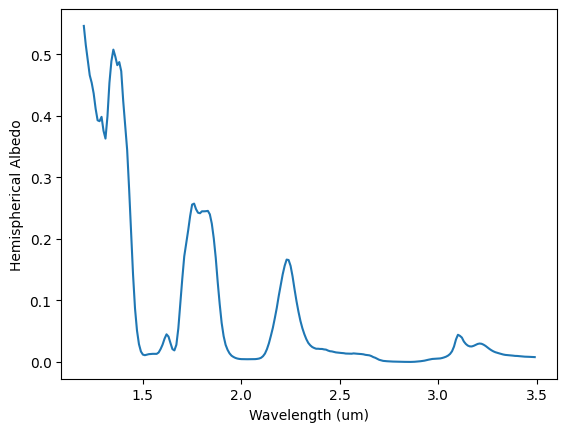

In [16]:
fig, axs = plt.subplots()
axs.plot(wavelength, albedo)
axs.set_ylabel("Hemispherical Albedo")
axs.set_xlabel("Wavelength (um)")

In [17]:
#del sim # free GPU memory for rendering
del sim

To visualize the geometry, we can use the CameraRayGenerator and render an image. The function below sets up such a simulation.

The Shading is done be calculating how well the reflected light aligns with a illuminaiton direction. The details can be skipped if you just want to see the results :)

In [18]:
from photontracer import CameraRayGenerator
from photontracer import Material, DIFFUSE

def render_geometry(simulation_cube, distance=180000, look_from_dir=[1,0.5,1], image_width=1000, light_direction=[0.5,-0.5,1], samples_per_pixel=20):
    sim = Simulation(gpu_id=0)

    sim.geometry = simulation_cube

    cam = CameraRayGenerator()
    cam.image_width = image_width
    cam.samples_per_pixel = samples_per_pixel
    cam.aspect_ratio = 1
    cam.vertical_up = (0.0, 0.0, 1.0)
    cam.look_at = (0.0, 0.0, -simulation_side_length / 2)
    cam.look_from = np.array(look_from_dir) * distance + np.array(cam.look_at)
    cam.vertical_fov = 30
    cam.focus_distance = float(np.linalg.norm(np.array(cam.look_from) - np.array(cam.look_at)))
    cam.defocus_angle = 0

    sim.ray_generator = cam

    vacuum = Material(REFRACTIVE, 1+0j)
    lambertian = Material(DIFFUSE, 0.8)
    sim.materials = [vacuum, lambertian]
    sim.wavelength_um = 1.0

    sim.outputs = [OutputType.RAY_STATE, OutputType.LAST_DIRECTION, OutputType.SCATTERING_COUNT]

    sim.run()

    last_dir = sim.get_output_buffer(OutputType.LAST_DIRECTION)
    state = sim.get_output_buffer(OutputType.RAY_STATE)
    scattering_count = sim.get_output_buffer(OutputType.SCATTERING_COUNT)


    light_vector = np.array(light_direction) / np.linalg.norm(np.array(light_direction))

    diag_shading = np.clip(np.einsum('...k,k->...', last_dir, light_vector), 0, 1)
    absorbed_ratio = (state == 0).sum(axis=2) / state.shape[2]

    diag_shading[state!=0] = np.nan
    absorbed_ratio.max()

    valid = np.isfinite(diag_shading)
    count = valid.sum(axis=2)
    total = np.nansum(diag_shading, axis=2)

    diag_shading_av = np.divide(
        total,
        count,
        out=np.full(total.shape, 0, dtype=diag_shading.dtype),
        where=count > 0,
    )
    diag_shading_av[scattering_count.sum(axis=2) == 0] = np.nan

    cmap = plt.cm.Blues_r.copy()
    cmap.set_bad(color="black")  # color for NaN values

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(diag_shading_av*absorbed_ratio, cmap=cmap)
    ax.axis("off")
    del sim

Selecting GPU device ID: 1/1
Starting simulation
Using device: NVIDIA GeForce RTX 3090
Finished raytracing in 1668 ms


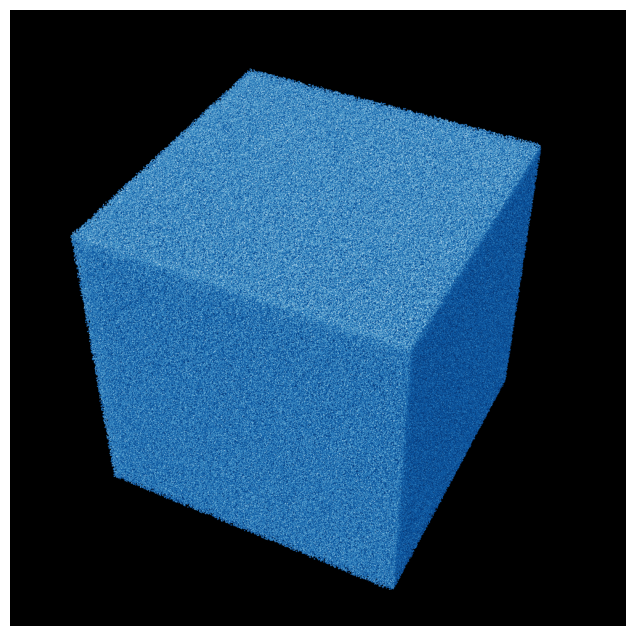

In [19]:
render_geometry(simulation_cube)  # takes 1.7s on a RTX3090, lower samples_per_pixel or image_width for faster rendering

Or we can render a detailed view of the surface. Here we see the particles overlapping due to the purely random distribution of the positions. A packing algorithm would be needed (e.g. HPMC, Hoomd-blue) to avoid this.

Selecting GPU device ID: 1/1
Starting simulation
Using device: NVIDIA GeForce RTX 3090
Finished raytracing in 12206 ms


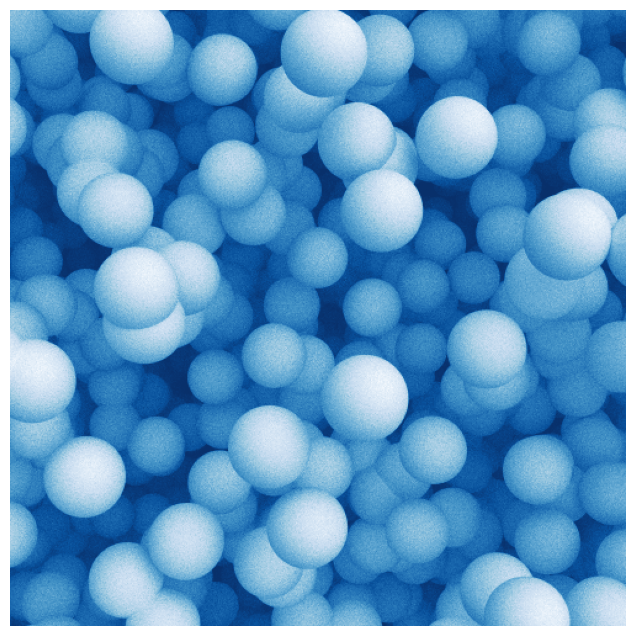

In [20]:
render_geometry(simulation_cube, distance = 40000, look_from_dir=[0,0,1], image_width=500, samples_per_pixel = 500) # takes 12s on a RTX3090, lower samples_per_pixel or image_width for faster rendering